# 11 — Mini Structural Demand Model (business baseline)

A deliberately **simple, transparent demand model** to open the analysis before the detailed per-region model. It forecasts biodiesel demand from the latest observed biodiesel volumes and one policy-growth assumption:

> **future biodiesel tonnes = 2025 biodiesel tonnes × biofuel mandate growth factor**

The absolute base is **actual biodiesel consumption** (`Consumo_Tm`) in 2025. The growth factor comes from Spain's broader **biofuel energy mandate** assumption (11.5% in 2025 → **14.0% in 2026** → **15.5% in 2027**). This does **not** mean the legal mandate is biodiesel-only; it uses total biofuel mandate growth as a simple proxy uplift for biodiesel demand. The model covers **Nacional + Madrid, Cataluña, Andalucía, Valencia** (regions are never summed; Nacional is the independently reported national total).

**What this is and isn't:**
- It is a **directional baseline** that grounds the forecast in business logic and regulation — not a precision model.
- It is a **demand** model: prices are a known historical co-driver but are **not** forecast here.
- **Honest caveat:** 2023–25 was an *adoption ramp* (the B3 blend only started Aug 2024), so biodiesel grew far faster than the headline mandate %. We therefore calibrate on the most recent, more mature **2025 biodiesel tonnes** and apply the biofuel mandate growth path as a directional uplift; the result is a baseline, not a guarantee.

## 0. Setup & inputs

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

REPO = Path().resolve().parent
INP  = REPO / 'data' / 'inputs'
OUT  = REPO / 'data' / 'outputs'

NAME = {'ESPAÑA': 'Nacional', 'Madrid, Comunidad de': 'Madrid', 'Cataluña': 'Cataluña',
        'Andalucía': 'Andalucía', 'Comunitat Valenciana': 'Valencia'}
SERIES = ['Nacional', 'Madrid', 'Cataluña', 'Andalucía', 'Valencia']
COLORS = {'Nacional': '#FF6B35', 'Madrid': '#004E89', 'Cataluña': '#1A936F',
          'Andalucía': '#C84B31', 'Valencia': '#8E44AD'}
MONTHS = ['{:02d}'.format(i) for i in range(1, 13)]

# Biodiesel (target) + Gasoleo A diesel market, by series, 2023-2025
m = pd.read_csv(INP / 'master_dataset.csv')
m = m[m['CCAA'].isin(NAME)].copy()
m['Serie'] = m['CCAA'].map(NAME)
m['Year']  = m['Fecha'].str[:4]
m['Mes']   = m['Fecha'].str[5:7]

# Legislated biofuel energy mandate (% of transport energy)
mandate = pd.read_csv(INP / 'mandato_biocarburantes.csv')
MAN = dict(zip(mandate['Año'].astype(str), mandate['Mandato_Energia_Pct']))
print('Energy mandate (%):', {y: MAN[y] for y in ['2023', '2024', '2025', '2026', '2027']})
print('Biofuel mandate growth factor applied to 2025 biodiesel tonnes: 2026 = x{:.3f},  2027 = x{:.3f}'.format(
      MAN['2026'] / MAN['2025'], MAN['2027'] / MAN['2025']))

Energy mandate (%): {'2023': 10.5, '2024': 11.0, '2025': 11.5, '2026': 14.0, '2027': 15.5}
Biofuel mandate growth factor applied to 2025 biodiesel tonnes: 2026 = x1.217,  2027 = x1.348


## 1. Historical biodiesel base and penetration context

The forecast itself uses **absolute 2025 biodiesel tonnes** as the base. Penetration = biodiesel ÷ Gasóleo A is shown only as context, because it explains how early the biodiesel adoption ramp still is: near-zero in 2023 and around 1% nationally in 2025.

In [2]:
rows = []
for s in SERIES:
    for y in ['2023', '2024', '2025']:
        d = m[(m['Serie'] == s) & (m['Year'] == y)]
        rows.append({'Serie': s, 'Year': y,
                     'Biodiesel_Tm': d['Consumo_Tm'].sum(),
                     'GasoleoA_Tm': d['GasoleoA_Tm'].sum(),
                     'Penetration_%': 100 * d['Consumo_Tm'].sum() / d['GasoleoA_Tm'].sum()})
hist = pd.DataFrame(rows)
print('Annual biodiesel penetration of the Gasoleo A market (%):')
print(hist.pivot(index='Serie', columns='Year', values='Penetration_%').reindex(SERIES).round(2).to_string())

Annual biodiesel penetration of the Gasoleo A market (%):
Year       2023  2024  2025
Serie                      
Nacional   0.03  0.31  1.01
Madrid     0.03  0.47  1.86
Cataluña   0.04  0.27  0.97
Andalucía  0.01  0.13  0.50
Valencia   0.02  0.16  0.53


## 2. The forecast (2026–2027)

**Method (one line per series):** take actual 2025 biodiesel tonnes, preserve the 2025 monthly seasonality, and scale the annual total using the biofuel mandate growth factor.
- **Central:** absolute biodiesel tonnes scale with the biofuel energy mandate assumption (2026: ×14.0/11.5; 2027: ×15.5/11.5).
- **Conservative:** absolute biodiesel tonnes stay at the 2025 level, with the same monthly shape.

Monthly values follow the 2025 seasonal shape of biodiesel demand. Gasóleo A is used only to report historical penetration context, not as a separate forecasted driver. (No price forecast — this is a demand model.)

In [3]:
r26 = MAN['2026'] / MAN['2025']
r27 = MAN['2027'] / MAN['2025']
fc_rows = []
for s in SERIES:
    d25 = m[(m['Serie'] == s) & (m['Year'] == '2025')]
    bio_by_month = d25.groupby('Mes')['Consumo_Tm'].sum()
    bio_annual_25 = bio_by_month.sum()
    share = bio_by_month / bio_annual_25                      # 2025 seasonal shares
    for yr, ratio in [('2026', r26), ('2027', r27)]:
        central_annual = bio_annual_25 * ratio
        cons_annual    = bio_annual_25 * 1.0
        for mo in MONTHS:
            fc_rows.append({'Fecha': '{}-{}'.format(yr, mo), 'Serie': s, 'Year': yr,
                            'Central': central_annual * share[mo],
                            'Conservador': cons_annual * share[mo]})
fc = pd.DataFrame(fc_rows)
annual = fc.groupby(['Serie', 'Year'])[['Central', 'Conservador']].sum().round(0)
print('Forecast biodiesel demand (Tm) — annual totals:')
print(annual.reindex(SERIES, level=0).to_string())

Forecast biodiesel demand (Tm) — annual totals:
                 Central  Conservador
Serie     Year                       
Nacional  2026  267415.0     219662.0
          2027  296066.0     219662.0
Madrid    2026   39641.0      32562.0
          2027   43888.0      32562.0
Cataluña  2026   41957.0      34465.0
          2027   46453.0      34465.0
Andalucía 2026   21640.0      17776.0
          2027   23959.0      17776.0
Valencia  2026   13128.0      10784.0
          2027   14535.0      10784.0


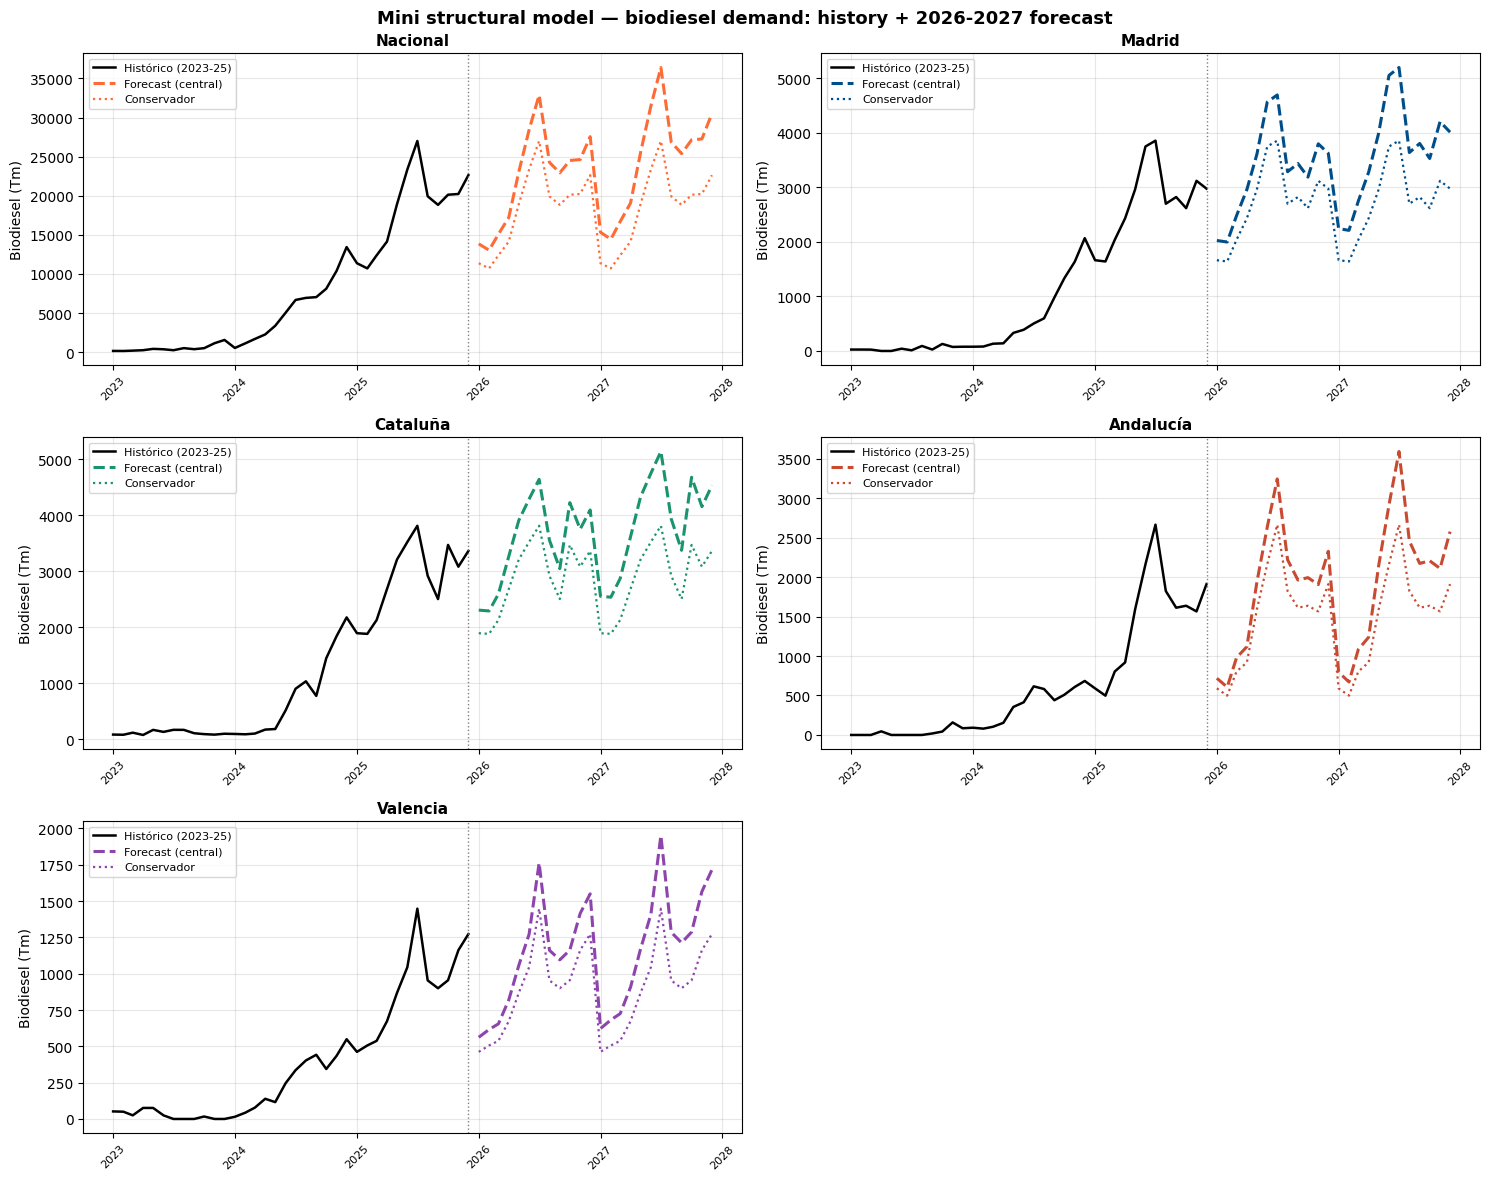

In [4]:
# History (2023-2025) + mini-model forecast (2026-2027)
fig, axes = plt.subplots(3, 2, figsize=(15, 12)); axes = axes.ravel()
cut = pd.to_datetime('2025-12')
for i, s in enumerate(SERIES):
    ax = axes[i]
    h = m[m['Serie'] == s].groupby('Fecha')['Consumo_Tm'].sum().reset_index()
    h['date'] = pd.to_datetime(h['Fecha'])
    f = fc[fc['Serie'] == s].copy(); f['date'] = pd.to_datetime(f['Fecha'])
    ax.plot(h['date'], h['Consumo_Tm'], '-', color='black', lw=1.8, label='Histórico (2023-25)')
    ax.plot(f['date'], f['Central'], '--', color=COLORS[s], lw=2.2, label='Forecast (central)')
    ax.plot(f['date'], f['Conservador'], ':', color=COLORS[s], lw=1.6, label='Conservador')
    ax.axvline(cut, color='grey', ls=':', lw=1)
    ax.set_title(s, fontsize=11, weight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_ylabel('Biodiesel (Tm)')
axes[-1].axis('off')
fig.suptitle('Mini structural model — biodiesel demand: history + 2026-2027 forecast', fontsize=13, weight='bold')
fig.tight_layout(); plt.show()

## 3. Cross-check against the detailed model

Two independent approaches. They will not match exactly, but they should point the same direction and sit in a similar range — which is the confidence-building message for the intro.

In [5]:
big = pd.read_csv(OUT / 'forecast_24m_sarima_rf_xgb.csv')
sel = pd.read_csv(OUT / 'metricas_final_seleccionado.csv')
big = big.merge(pd.DataFrame(zip(sel['Target'], sel['Model']), columns=['Target', 'Model']),
                on=['Target', 'Model'])
big['Year'] = big['Fecha'].str[:4]
big26 = big[big['Year'] == '2026'].groupby('Target')['Forecast'].sum()
actual25 = m[m['Year'] == '2025'].groupby('Serie')['Consumo_Tm'].sum()
mini26 = fc[fc['Year'] == '2026'].groupby('Serie')['Central'].sum()
cmp = pd.DataFrame({'2025_actual': actual25,
                    'Mini_central_2026': mini26,
                    'BigModel_2026': big26}).reindex(SERIES).round(0)
cmp['Mini_growth_%']  = (100 * (cmp['Mini_central_2026'] / cmp['2025_actual'] - 1)).round(1)
cmp['Big_growth_%']   = (100 * (cmp['BigModel_2026'] / cmp['2025_actual'] - 1)).round(1)
print('2026 biodiesel demand (Tm): mini structural vs detailed model')
print(cmp.to_string())

2026 biodiesel demand (Tm): mini structural vs detailed model
           2025_actual  Mini_central_2026  BigModel_2026  Mini_growth_%  Big_growth_%
Nacional        219662           267415.0       312379.0           21.7          42.2
Madrid           32562            39641.0        44848.0           21.7          37.7
Cataluña         34465            41957.0        33865.0           21.7          -1.7
Andalucía        17776            21640.0        29441.0           21.7          65.6
Valencia         10784            13128.0        17656.0           21.7          63.7


## Summary & caveats

- **Use as the intro:** a back-of-envelope **demand** model — *2025 biodiesel tonnes × biofuel mandate growth factor* — that ties the forecast to observed biodiesel volumes and the mandate path (energy obligation rising 11.5% → 14.0% in 2026 → 15.5% in 2027). It lands in a similar range to the detailed per-region model, which is reassuring to show before diving into the technical model.
- **Caveats to state on the slide:**
  - 2023–25 was an **adoption ramp** from near-zero; biodiesel volumes grew much faster than the mandate %. So this projects the *recent 2025 biodiesel base* forward using biofuel mandate growth — a directional baseline, not a precise prediction.
  - **Scope:** observed biodiesel penetration (~1%) sits below the nominal B3 blend because the energy obligation is met by a *mix* of biofuels (HVO, bioethanol). The 2028 step to a 7.5% physical blend is where 'biodiesel' vs broader 'eco-fuels' really diverges — outside this 2026-27 window but worth flagging.
  - Gasóleo A is **not forecast separately** in this mini model; it is used only to show historical biodiesel penetration. A declining-diesel scenario would lower these figures if translated into a stricter market-size model.
- **Not a price model.** Prices are a known historical co-driver but are not forecast here.